In [3]:
#importing dependencies

import numpy as np
import pickle as pkl
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50,preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalMaxPooling2D

from sklearn.neighbors import NearestNeighbors
import os
from numpy.linalg import norm


In [1]:
#Extract file names from the folder

In [4]:
filenames = []
for file in os.listdir('images'):
    filenames.append(os.path.join('images',file))

In [5]:
len(filenames)

3006

In [ ]:
#Load the ResNet50 model

In [6]:
model = ResNet50(weights='imagenet',include_top=False,input_shape=(224,224,3))
model.trainable = False

model = tf.keras.Sequential([model,GlobalMaxPooling2D()])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
#Extract features from the images

In [7]:
img = image.load_img(filenames[0],target_size=(224,224))
img_array = image.img_to_array(img)
img_expand_dim = np.expand_dims(img_array,axis=0)
img_preprocessed = preprocess_input(img_expand_dim)
result = model.predict(img_preprocessed).flatten()
norm_result = result/norm(result)
norm_result

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([0.0133517 , 0.0345972 , 0.00199125, ..., 0.01116223, 0.        ,
       0.02908587], dtype=float32)

In [8]:
def extract_features_from_images(image_path,model):
    img = image.load_img(image_path,target_size=(224,224))
    img_array = image.img_to_array(img)
    img_expand_dim = np.expand_dims(img_array,axis=0)
    img_preprocessed = preprocess_input(img_expand_dim)
    result = model.predict(img_preprocessed).flatten()
    norm_result = result/norm(result)
    return norm_result

In [9]:
extract_features_from_images(filenames[0],model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([0.0133517 , 0.0345972 , 0.00199125, ..., 0.01116223, 0.        ,
       0.02908587], dtype=float32)

In [10]:
image_features = []
for file in filenames:
    image_features.append(extract_features_from_images(file,model))

image_features

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━

[array([0.0133517 , 0.0345972 , 0.00199125, ..., 0.01116223, 0.        ,
        0.02908587], dtype=float32),
 array([0.01535033, 0.02037982, 0.00667319, ..., 0.03495873, 0.06043361,
        0.05826424], dtype=float32),
 array([0.00597739, 0.0180956 , 0.00779335, ..., 0.01798957, 0.05528646,
        0.0187211 ], dtype=float32),
 array([0.01094171, 0.03189306, 0.00976565, ..., 0.01452741, 0.03263758,
        0.02673177], dtype=float32),
 array([0.02109894, 0.00947092, 0.02455011, ..., 0.00534397, 0.        ,
        0.02408426], dtype=float32),
 array([0.00715045, 0.02610746, 0.00779306, ..., 0.01159337, 0.00782976,
        0.01654727], dtype=float32),
 array([0.00931861, 0.03343883, 0.01384107, ..., 0.01255034, 0.        ,
        0.02057872], dtype=float32),
 array([0.00478125, 0.03533643, 0.00613557, ..., 0.00341997, 0.01121646,
        0.02306852], dtype=float32),
 array([0.01779338, 0.04637162, 0.02127609, ..., 0.00451287, 0.01927784,
        0.00671999], dtype=float32),
 array([0.

In [11]:
Image_features = pkl.dump(image_features,open('Image_features.pkl','wb'))

In [12]:
filenames = pkl.dump(filenames,open('filenames.pkl','wb'))

In [ ]:
#Loading pickle files

In [13]:
Image_features = pkl.load(open('Image_features.pkl','rb'))

In [14]:
filenames = pkl.load(open('filenames.pkl','rb'))

In [15]:
np.array(Image_features).shape

(3006, 2048)

In [ ]:
#Finding similar images

In [16]:
neighbors = NearestNeighbors(n_neighbors=6,algorithm='brute',metric='euclidean')

In [17]:
neighbors.fit(Image_features)

NearestNeighbors(algorithm='brute', metric='euclidean', n_neighbors=6)

In [18]:
input_image = extract_features_from_images('chair3.jpg',model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


In [19]:
distance,indices = neighbors.kneighbors([input_image])

In [20]:
indices

array([[  2,   0,   1, 146, 301, 457]])

In [21]:
from IPython.display import Image

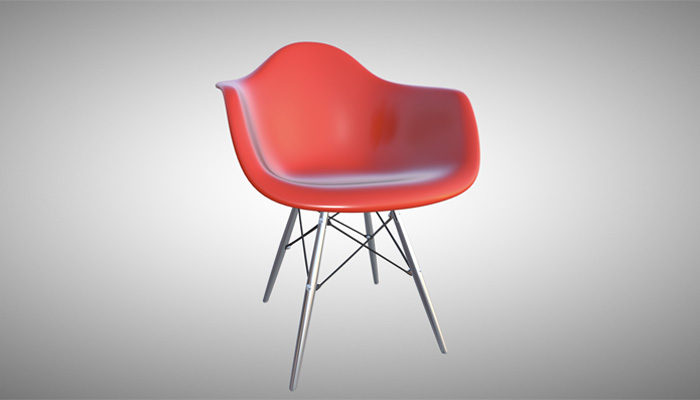

In [22]:
Image('chair3.jpg')

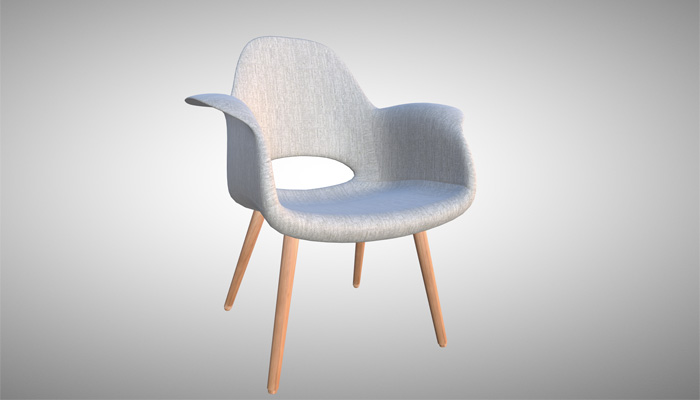

In [23]:
Image(filenames[indices[0][1]])

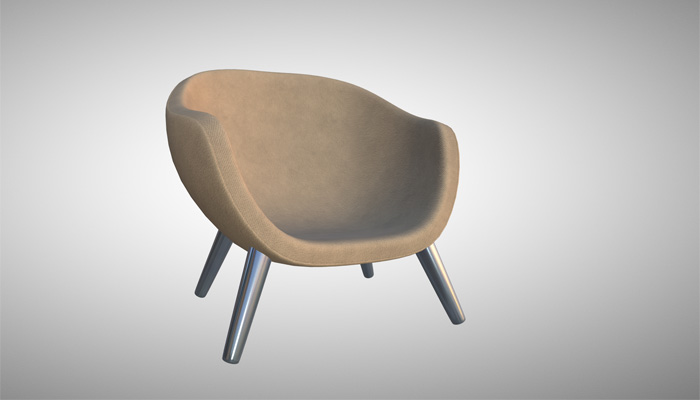

In [ ]:
Image(filenames[indices[0][2]])

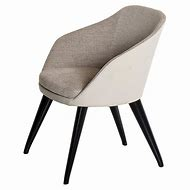

In [ ]:
Image(filenames[indices[0][3]])

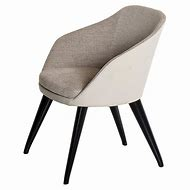

In [ ]:
Image(filenames[indices[0][4]])

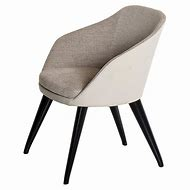

In [ ]:
Image(filenames[indices[0][5]])